<a href="https://colab.research.google.com/github/soumiaboufenara-cpu/demographic-data-analyze/blob/main/Projet%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#pandas:Data manipulation and analusis
import pandas as pd
#Numpy:numerical calculation and arrays
import numpy as np
#matplotlib: data visulation and plotting
import matplotlib.pyplot as plt
#split data into training and testing sets
from sklearn.model_selection import train_test_split
#rando forest regression model
from sklearn.ensemble import RandomForestRegressor
#model performance evaluation matrics
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
df=pd.read_csv("03_Dataset_distillation_unit_hourly_data.csv")
df["timestap"]=pd.to_datetime(df["timestamp"])

# **A) Data Cleaning**




In [3]:
#A) Data Cleaning
df.info()
df.describe()
#.interpolate: تعويض القيم الناقصة بقيمة تقديرية اعتمادا على القيم المحيطة بها
df["condenser_outlet_temp_C"]=df["condenser_outlet_temp_C"].interpolate()
#.drop_duplicates() : sumprimer les linges repétée
df=df.drop_duplicates()
print(df.shape)
#isna():يحدد القيم الناقصة ب 1 في ل عمود; sum يجمع عدد القيم الناقصة
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   timestamp                4320 non-null   object        
 1   shift                    4320 non-null   object        
 2   event                    4320 non-null   object        
 3   feed_flow_tph            4320 non-null   float64       
 4   feed_composition_pct     4320 non-null   float64       
 5   feed_temperature_C       4320 non-null   float64       
 6   column_pressure_bar      4320 non-null   float64       
 7   reflux_ratio             4320 non-null   float64       
 8   steam_flow_tph           4320 non-null   float64       
 9   cooling_water_m3h        4320 non-null   float64       
 10  condenser_outlet_temp_C  4320 non-null   float64       
 11  top_product_purity_pct   4320 non-null   float64       
 12  bottom_impurity_pct      4320 non-

In [4]:
#A) Data Cleaning
df.info()
df.describe()
df.head()
#.interpolate: تعويض القيم الناقصة بقيمة تقديرية اعتمادا على القيم المحيطة بها
df["condenser_outlet_temp_C"]=df["condenser_outlet_temp_C"].interpolate()
#.drop_duplicates() : sumprimer les linges repétée
df=df.drop_duplicates()
print(df.shape)
#isna():يحدد القيم الناقصة ب 1 في ل عمود; sum يجمع عدد القيم الناقصة
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   timestamp                4320 non-null   object        
 1   shift                    4320 non-null   object        
 2   event                    4320 non-null   object        
 3   feed_flow_tph            4320 non-null   float64       
 4   feed_composition_pct     4320 non-null   float64       
 5   feed_temperature_C       4320 non-null   float64       
 6   column_pressure_bar      4320 non-null   float64       
 7   reflux_ratio             4320 non-null   float64       
 8   steam_flow_tph           4320 non-null   float64       
 9   cooling_water_m3h        4320 non-null   float64       
 10  condenser_outlet_temp_C  4320 non-null   float64       
 11  top_product_purity_pct   4320 non-null   float64       
 12  bottom_impurity_pct      4320 non-

In [5]:
df.describe()

,feed_flow_tph,feed_composition_pct,feed_temperature_C,column_pressure_bar,reflux_ratio,steam_flow_tph,cooling_water_m3h,condenser_outlet_temp_C,top_product_purity_pct,bottom_impurity_pct,product_flow_tph,yield_pct,steam_energy_GJ_h,energy_intensity_GJ_t,pump_vibration_mm_s,downtime_flag,timestap
count,4320.000000,4320.000000,4320.000000,4320.000000,4320.000000,4320.000000,4320.000000,4320.000000,4320.000000,4320.000000,4320.000000,4320.000000,4320.000000,4320.000000,4320.000000,4320.000000,4320
mean,51.981873,63.092713,104.006014,1.550756,2.553834,3.566969,118.017227,35.000264,98.796609,0.721129,46.817505,90.072245,3.284163,70.355410,2.201875,0.003009,2026-03-31 23:29:59.999999744
min,44.000000,56.770000,99.060000,1.460000,2.150000,3.100000,105.000000,33.500000,97.464000,0.512000,39.240000,86.910000,2.900000,57.313000,1.200000,0.000000,2026-01-01 00:00:00
25%,49.310000,61.330000,102.740000,1.518000,2.444000,3.348000,111.217500,34.730000,98.459000,0.677000,44.480000,89.470000,3.078000,65.425750,2.000000,0.000000,2026-02-14 23:45:00
50%,51.950000,63.170000,104.030000,1.550000,2.554500,3.574000,118.070000,35.000000,98.795500,0.720000,46.790000,90.060000,3.275500,69.620500,2.200000,0.000000,2026-03-31 23:30:00
75%,54.580000,64.850000,105.250000,1.584000,2.664000,3.777000,124.800000,35.270000,99.145000,0.765000,49.112500,90.670000,3.456250,74.164750,2.410000,0.000000,2026-05-15 23:15:00
max,60.450000,68.900000,109.500000,1.660000,2.950000,4.100000,134.470000,36.480000,99.850000,0.999000,54.430000,93.760000,4.618000,102.511000,3.270000,1.000000,2026-06-29 23:00:00
std,3.149613,2.153166,1.730109,0.043239,0.146406,0.271551,7.539381,0.393418,0.458595,0.064955,2.812242,0.883618,0.261340,6.606713,0.293449,0.054780,NaN


In [6]:
df["quality_status"].unique()

array(['On-Spec', 'Off-Spec'], dtype=object)

# **B) Process KPIs ( key performance Indicator )**

1.   on spec rate
2.  average purity
3. average_yiel
4. average energy
5. average product



In [7]:

on_spec_rate = (df["quality_status"] == "On-Spec").mean()*100
average_purity=df["top_product_purity_pct"].mean()
average_yiel=df["yield_pct"].mean()
average_energy=df["energy_intensity_GJ_t"].mean()
average_product_flow = df["product_flow_tph"].mean()
print("On-spec rate:", round(on_spec_rate, 2), "%")
print("average_purity:",round(average_purity,2),'%')
print("average_yiel:",round(average_yiel,2),'%')
print("average_energy:",round(average_energy,2),'%')
print("average_procuct_flow:",round(average_product_flow,2),'%')

On-spec rate: 32.85 %
average_purity: 98.8 %
average_yiel: 90.07 %
average_energy: 70.36 %
average_procuct_flow: 46.82 %


In [8]:
df.head()

,timestamp,shift,event,feed_flow_tph,feed_composition_pct,feed_temperature_C,column_pressure_bar,reflux_ratio,steam_flow_tph,cooling_water_m3h,...,bottom_impurity_pct,product_flow_tph,yield_pct,steam_energy_GJ_h,energy_intensity_GJ_t,pump_vibration_mm_s,pump_status,quality_status,downtime_flag,timestap
0,2026-01-01 00:00:00,Night,Normal,52.43,63.08,104.82,1.563,2.825,3.643,115.91,...,0.674,47.70,90.98,3.219,67.492,1.66,Normal,On-Spec,0,2026-01-01 00:00:00
1,2026-01-01 01:00:00,Night,Normal,51.58,63.90,106.34,1.568,2.535,3.780,119.15,...,0.738,46.64,90.42,3.408,73.071,1.99,Normal,Off-Spec,0,2026-01-01 01:00:00
2,2026-01-01 02:00:00,Night,Normal,55.05,62.30,104.13,1.587,2.493,3.538,119.46,...,0.685,48.64,88.36,3.187,65.520,2.26,Normal,Off-Spec,0,2026-01-01 02:00:00
3,2026-01-01 03:00:00,Night,Normal,56.15,63.91,103.94,1.541,2.771,3.932,122.25,...,0.685,49.59,88.32,3.647,73.538,2.09,Normal,Off-Spec,0,2026-01-01 03:00:00
4,2026-01-01 04:00:00,Night,Normal,52.73,62.86,105.96,1.585,2.738,3.415,123.98,...,0.779,46.70,88.55,2.978,63.772,2.21,Normal,Off-Spec,0,2026-01-01 04:00:00


In [9]:
print(df["quality_status"].unique())
print(df['quality_status'].value_counts())
df["month"]=df["timestap"].dt.month_name()
print(df[df["quality_status"] == "Off-Spec"].groupby("month").size())
df["day"]=df["timestap"].dt.day_name()
print(df[df["quality_status"] == "Off-Spec"].groupby("day").size())

['On-Spec' 'Off-Spec']
quality_status
Off-Spec    2901
On-Spec     1419
Name: count, dtype: int64
month
April       487
February    451
January     502
June        476
March       476
May         509
dtype: int64
day
Friday       417
Monday       427
Saturday     416
Sunday       428
Thursday     425
Tuesday      395
Wednesday    393
dtype: int64


**how often the process is off-spec:**
Off-Spec    2901 h
On-Spec     1419 h  
The process achieved an On spec Rate 32.85% indicating tha most production periods were Off-spec


# **3) Shift Analusis**

In [10]:
print(df["shift"].unique())

['Night' 'Morning' 'Evening']


In [11]:
shift_KPI=df.groupby("shift")[["top_product_purity_pct","yield_pct","energy_intensity_GJ_t","product_flow_tph"]].mean()
print(shift_KPI)

         top_product_purity_pct  yield_pct  energy_intensity_GJ_t  \
shift                                                               
Evening               99.185828  90.185944              74.402192   
Morning               98.741085  90.069604              68.800498   
Night                 98.462913  89.961187              67.863541   

         product_flow_tph  
shift                      
Evening         44.131500  
Morning         47.186750  
Night           49.134264  


# **Whether operating shifts behave differently:**
The operating shifts showed different performance.
- the evening shift achieved the highest product purity and yield with a highest energie
- the night shift had the lowest energy consumation and the highest product flow, but it showed bthe lowest purity
- the morning shift had interediate performance


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   timestamp                4320 non-null   object        
 1   shift                    4320 non-null   object        
 2   event                    4320 non-null   object        
 3   feed_flow_tph            4320 non-null   float64       
 4   feed_composition_pct     4320 non-null   float64       
 5   feed_temperature_C       4320 non-null   float64       
 6   column_pressure_bar      4320 non-null   float64       
 7   reflux_ratio             4320 non-null   float64       
 8   steam_flow_tph           4320 non-null   float64       
 9   cooling_water_m3h        4320 non-null   float64       
 10  condenser_outlet_temp_C  4320 non-null   float64       
 11  top_product_purity_pct   4320 non-null   float64       
 12  bottom_impurity_pct      4320 non-

# **4. CORRELATION ANALYSIS**
Mesuere ther relation between the variabes and purity

In [13]:
#Variable Names
Feature=["feed_flow_tph","feed_composition_pct","feed_temperature_C","column_pressure_bar","reflux_ratio",
    "steam_flow_tph",
    "cooling_water_m3h",
    "top_product_purity_pct",
    "yield_pct",
    "energy_intensity_GJ_t",
    "pump_vibration_mm_s"]

In [14]:
#corr it's in pandas  لحساب معامل الارتبالط بين كل الاعمدة
#.drop("") باش متضربش في هدا العمود
#.sort_valeues للتنظيم من الاصغر للاكبر
correlation=df[Feature].corr()["top_product_purity_pct"].drop("top_product_purity_pct").sort_values()
print(correlation)

feed_flow_tph           -0.873741
cooling_water_m3h       -0.802174
feed_temperature_C      -0.632688
pump_vibration_mm_s     -0.584226
steam_flow_tph          -0.252569
feed_composition_pct    -0.099591
column_pressure_bar     -0.037131
yield_pct                0.173116
reflux_ratio             0.369213
energy_intensity_GJ_t    0.401786
Name: top_product_purity_pct, dtype: float64


# **Which operating variables are associated with purity losses**
correlation analysiis identified bthe operaton variables that have positive or negative relatinships with product puriy

# 5) Time series **plot**

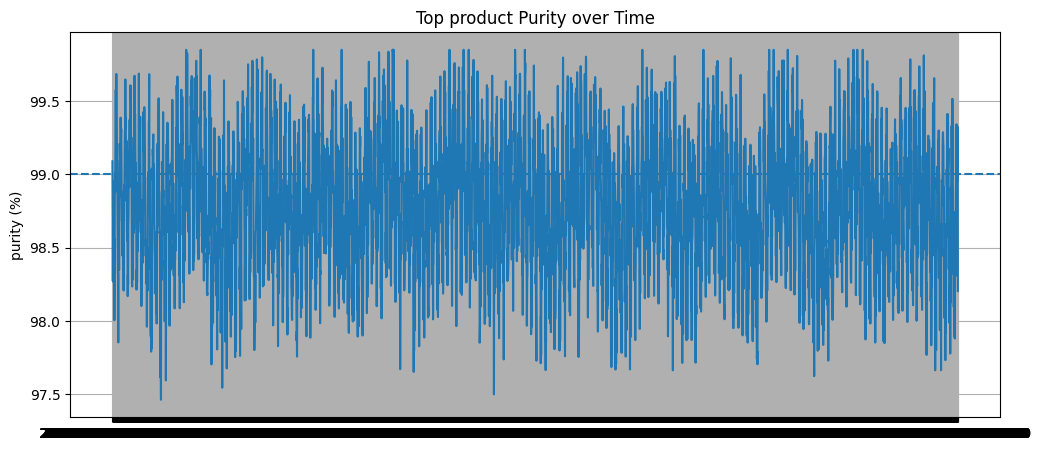

In [15]:
plt.figure(figsize=(12,5))
plt.plot(df["timestamp"],df["top_product_purity_pct"])
plt.axhline(99.0,linestyle="--")
plt.title("Top product Purity over Time")
plt.xlabl=("Time")
plt.ylabel("purity (%)")
plt.grid(True)
plt.show()

# **6)**OFF-SPEC ANALYSIS

In [16]:
off_spec = df[df["quality_status"] == "Off-Spec"]
print("off-spec hours",len(off_spec))
offspec= off_spec.groupby("event").size().sort_values(ascending=False)
print(offspec)

off-spec hours 2901
event
Normal                    2838
Heat-transfer loss          18
Reflux control issue        17
Condenser fouling           16
Feed composition upset      12
dtype: int64


In [17]:
print(off_spec[[
        "timestamp",
        "event",
        "feed_flow_tph",
        "reflux_ratio",
        "steam_flow_tph",
        "column_pressure_bar",
        "top_product_purity_pct",
        "bottom_impurity_pct"
    ]].head(20))


              timestamp   event  feed_flow_tph  reflux_ratio  steam_flow_tph  \
1   2026-01-01 01:00:00  Normal          51.58         2.535           3.780   
2   2026-01-01 02:00:00  Normal          55.05         2.493           3.538   
3   2026-01-01 03:00:00  Normal          56.15         2.771           3.932   
4   2026-01-01 04:00:00  Normal          52.73         2.738           3.415   
5   2026-01-01 05:00:00  Normal          54.04         2.603           3.698   
6   2026-01-01 06:00:00  Normal          56.18         2.654           3.744   
7   2026-01-01 07:00:00  Normal          55.42         2.656           3.870   
8   2026-01-01 08:00:00  Normal          55.44         2.632           3.837   
9   2026-01-01 09:00:00  Normal          53.63         2.503           3.643   
10  2026-01-01 10:00:00  Normal          55.23         2.396           3.974   
11  2026-01-01 11:00:00  Normal          54.12         2.543           3.500   
12  2026-01-01 12:00:00  Normal         

Which disturbances are associated with degraded performance:

OFF-SPEC ANALYSIS by event determined which disturbances most frequenty caused off spec production

# **7) PREDICTIVE MODEL**

In [18]:
#from sklearn labrery
model_features=["feed_flow_tph",
    "feed_composition_pct",
    "feed_temperature_C",
    "column_pressure_bar",
    "reflux_ratio",
    "steam_flow_tph",
    "cooling_water_m3h",
    "condenser_outlet_temp_C"]
x=df[model_features]
y=df["top_product_purity_pct"]
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.20, random_state=42)
model=RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(x_train,y_train)
pred=model.predict(x_test)
mea=mean_absolute_error(y_test,pred)
r2=r2_score(y_test,pred)
importance=pd.Series(model.feature_importances_,index=model_features).sort_values(ascending=False)
print(importance)

feed_flow_tph              0.783844
reflux_ratio               0.145898
feed_composition_pct       0.016391
column_pressure_bar        0.012057
feed_temperature_C         0.012018
cooling_water_m3h          0.010457
steam_flow_tph             0.009696
condenser_outlet_temp_C    0.009639
dtype: float64


The feature importance showed  the Feed flow rate is the most iportant variable for predicting the top product purity and Reflux ratio also has an important influence on product purity, the others variables have relatively low importancfe.

# **8. OPERATING WINDOW**

In [19]:
energy_threshold =df["energy_intensity_GJ_t"].quantile(0.40)
good_region = df[(df["top_product_purity_pct"] >= 99.0) &(df["energy_intensity_GJ_t"] <= energy_threshold)]
print(good_region[[
    "reflux_ratio",
    "steam_flow_tph",
    "column_pressure_bar",
    "top_product_purity_pct",
    "energy_intensity_GJ_t"]].describe())


       reflux_ratio  steam_flow_tph  column_pressure_bar  \
count    344.000000      344.000000           344.000000   
mean       2.630785        3.261922             1.547703   
std        0.131648        0.146290             0.043947   
min        2.258000        3.100000             1.460000   
25%        2.550750        3.121500             1.512000   
50%        2.636000        3.239000             1.546000   
75%        2.719250        3.359250             1.583000   
max        2.948000        3.814000             1.659000   

       top_product_purity_pct  energy_intensity_GJ_t  
count              344.000000             344.000000  
mean                99.204038              65.244680  
std                  0.165303               1.938582  
min                 99.000000              59.344000  
25%                 99.076500              63.829750  
50%                 99.169500              65.425500  
75%                 99.290250              66.794750  
max                

The operating vwindow analysis identified the conditions assosiated with high product purity and low energy